# Baseline XGBoost — 30-Day Readmission

Thin runner/display layer only — all feature engineering, label logic, and CV logic live in `src/features/build_dataset.py` and `src/models/train_baseline.py`. This notebook does not reimplement any of it.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))

from src.features.build_dataset import NON_FEATURE_COLS, build_feature_table
from src.models.train_baseline import run_cv

## Build features

In [2]:
df = build_feature_table(data_dir=Path("..") / "data" / "raw")
feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
X, y = df[feature_cols], df["readmit_30d"]

n_pos = y.sum()
print(f"cohort: {len(df)} admissions, {len(feature_cols)} features")
print(f"positives: {n_pos} ({100 * y.mean():.1f}%)")

cohort: 129 admissions, 23 features
positives: 11 (8.5%)


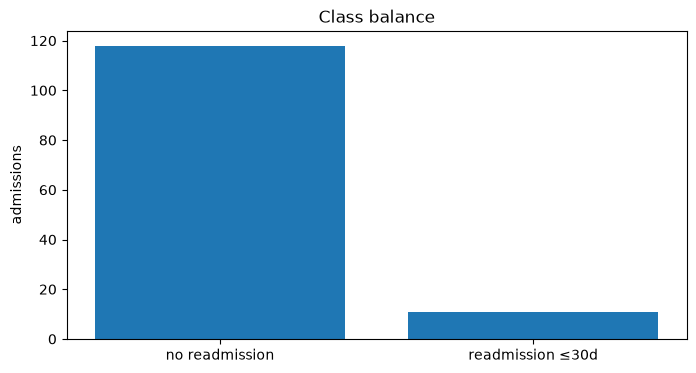

In [3]:
plt.figure(figsize=(8, 4))
plt.bar(["no readmission", "readmission \u226430d"], [len(y) - n_pos, n_pos])
plt.ylabel("admissions")
plt.title("Class balance")
plt.show()

## Cross-validated baseline

In [4]:
report, models = run_cv(X, y)
report

,fold,n_test,n_pos_test,roc_auc,pr_auc
0,1,26,2,0.395833,0.093074
1,2,26,2,0.458333,0.102381
2,3,26,2,0.583333,0.129167
3,4,26,3,0.521739,0.175000
4,5,25,2,0.847826,0.375000


In [5]:
print(f"roc_auc  mean={report['roc_auc'].mean():.3f}  std={report['roc_auc'].std():.3f}")
print(f"pr_auc   mean={report['pr_auc'].mean():.3f}  std={report['pr_auc'].std():.3f}")

roc_auc  mean=0.561  std=0.175
pr_auc   mean=0.175  std=0.116


## Feature importance

Averaged across the 5 fold models, with std-dev error bars showing how stable each feature's importance is across folds — not a single-fit snapshot.

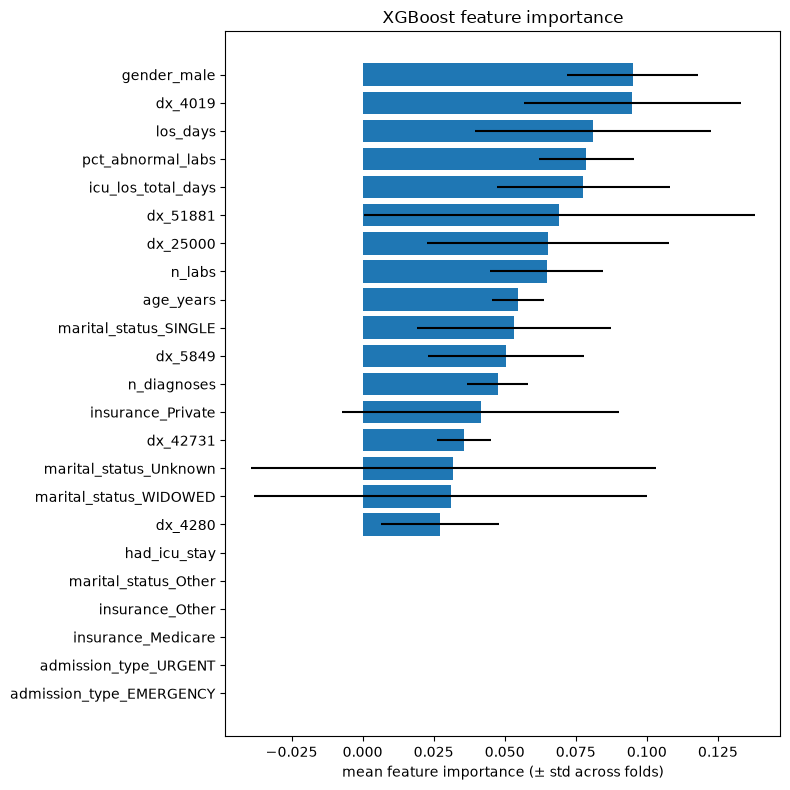

In [6]:
importances = pd.DataFrame(
    [m.feature_importances_ for m in models], columns=feature_cols
)
mean_importance = importances.mean().sort_values(ascending=True)
std_importance = importances.std()[mean_importance.index]

plt.figure(figsize=(8, 8))
plt.barh(mean_importance.index, mean_importance.values, xerr=std_importance.values)
plt.xlabel("mean feature importance (\u00b1 std across folds)")
plt.title("XGBoost feature importance")
plt.tight_layout()
plt.show()